In [1]:
#import divorces_2000-2015_translated.csv
import pandas as pd
from datetime import datetime
# Load the dataset
df = pd.read_csv('divorces_2000-2015_translated.csv')

# Display the structure of the dataframe
print(df.info())

# Display the columns of the dataframe
print(df.columns)
# Display the number of rows and columns in the dataframe
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")

# Display the first few rows of the dataframe
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4923 entries, 0 to 4922
Data columns (total 41 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Divorce_date                          4923 non-null   object 
 1   Type_of_divorce                       4923 non-null   object 
 2   Nationality_partner_man               4922 non-null   object 
 3   DOB_partner_man                       4542 non-null   object 
 4   Place_of_birth_partner_man            4797 non-null   object 
 5   Birth_municipality_of_partner_man     4794 non-null   object 
 6   Birth_federal_partner_man             4795 non-null   object 
 7   Birth_country_partner_man             4796 non-null   object 
 8   Age_partner_man                       4816 non-null   float64
 9   Residence_municipality_partner_man    4599 non-null   object 
 10  Residence_federal_partner_man         4600 non-null   object 
 11  Residence_country

,Divorce_date,Type_of_divorce,Nationality_partner_man,DOB_partner_man,Place_of_birth_partner_man,Birth_municipality_of_partner_man,Birth_federal_partner_man,Birth_country_partner_man,Age_partner_man,Residence_municipality_partner_man,...,Marriage_certificate_municipality,Marriage_certificate_federal,Level_of_education_partner_man,Employment_status_partner_man,Level_of_education_partner_woman,Employment_status_partner_woman,Marriage_duration,Marriage_duration_months,Num_Children,Custody
0,9/6/06,Necesario,MEXICANA,18/12/75,XALAPA - ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,30.0,XALAPA,...,XALAPA,VERACRUZ,SECUNDARIA,OBRERO,SECUNDARIA,EMPLEADO,5.0,NaN,1.0,NaN
1,1/2/00,Voluntario,MEXICANA,NaN,NaN,NaN,NaN,NaN,47.0,NaN,...,XALAPA,VERACRUZ,PREPARATORIA,ESTABLECIMIENTO,PREPARATORIA,EMPLEADO,NaN,NaN,NaN,NaN
2,1/2/05,Necesario,MEXICANA,22/2/55,XALAPA - ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,49.0,NaN,...,XALAPA,VERACRUZ,PREPARATORIA,OBRERO,NaN,TRABAJADOR POR CUENTA PROPIA EN VIA PUBLICA,NaN,NaN,NaN,NaN
3,1/2/06,Necesario,MEXICANA,20/1/64,XALAPA - ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,42.0,XALAPA,...,XALAPA,VERACRUZ,PROFESIONAL,EMPLEADO,PREPARATORIA,EMPLEADO,18.0,NaN,2.0,MADRE
4,1/2/06,Necesario,MEXICANA,30/10/75,XALAPA - ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,30.0,COATEPEC,...,XALAPA,VERACRUZ,PROFESIONAL,EMPLEADO,PREPARATORIA,NO TRABAJA,7.0,NaN,2.0,MADRE


In [2]:
# only get these cols: Divorce_date  DOB_partner_man DOB_partner_woman Date_of_marriage Marriage_duration Marriage_duration_months Num_Children
df = df[['Divorce_date', 'DOB_partner_man', 'DOB_partner_woman', 'Date_of_marriage', 'Marriage_duration', 'Marriage_duration_months', 'Num_Children']]

In [3]:
df.head()

,Divorce_date,DOB_partner_man,DOB_partner_woman,Date_of_marriage,Marriage_duration,Marriage_duration_months,Num_Children
0,9/6/06,18/12/75,8/1/83,26/6/00,5.0,NaN,1.0
1,1/2/00,NaN,NaN,17/2/77,NaN,NaN,NaN
2,1/2/05,22/2/55,21/3/47,18/12/75,NaN,NaN,NaN
3,1/2/06,20/1/64,NaN,3/12/87,18.0,NaN,2.0
4,1/2/06,30/10/75,13/10/78,14/11/98,7.0,NaN,2.0


In [4]:
#check how many NaN values in each column
print(df.isna().sum())  

Divorce_date                   0
DOB_partner_man              381
DOB_partner_woman            452
Date_of_marriage               0
Marriage_duration            235
Marriage_duration_months    3368
Num_Children                1912
dtype: int64


In [5]:
def convert_dob_columns(df):
    # Convert DOB_partner_man
    df['DOB_partner_man'] = pd.to_datetime(
        df['DOB_partner_man'], 
        format='%d/%m/%y',  # Current format is DD/MM/YY
        errors='coerce'     # Handle invalid or NaN values
    )
    
    # Convert DOB_partner_woman
    df['DOB_partner_woman'] = pd.to_datetime(
        df['DOB_partner_woman'], 
        format='%d/%m/%y', 
        errors='coerce'
    )
    
    return df
# Assume your data is in a DataFrame called 'df'
def fix_dob_columns(df):
    # Define current date for validation
    current_date = datetime(2025, 7, 11)
    
    # Convert DOB_partner_man
    df['DOB_partner_man'] = pd.to_datetime(
        df['DOB_partner_man'], 
        format='%d/%m/%y',  # Input format is DD/MM/YY
        errors='coerce'     # Handle invalid or NaN values
    )
    
    # Convert DOB_partner_woman
    df['DOB_partner_woman'] = pd.to_datetime(
        df['DOB_partner_woman'], 
        format='%d/%m/%y', 
        errors='coerce'
    )
    
    # [Change 1]: Adjust years to 1900s for two-digit years
    for col in ['DOB_partner_man', 'DOB_partner_woman']:
        # Find dates with year >= 2000 and adjust them
        mask = (df[col].notnull()) & (df[col].dt.year >= 2000)
        df.loc[mask, col] = df.loc[mask, col].apply(
            lambda x: x.replace(year=x.year - 100)
        )
    
    # [Change 2]: Mark future dates (after 2025-07-11) as NaT
    for col in ['DOB_partner_man', 'DOB_partner_woman']:
        mask_future = (df[col].notnull()) & (df[col] > current_date)
        df.loc[mask_future, col] = pd.NaT
    
    return df

# Apply the fix
df = fix_dob_columns(df)

# Check the result
print("After fixing DOB columns:")
print(df[['DOB_partner_man', 'DOB_partner_woman']])

# Check for any remaining future dates
print("\nChecking for future dates:")
for col in ['DOB_partner_man', 'DOB_partner_woman']:
    future_dates = df[df[col] > datetime(2025, 7, 11)][col]
    if not future_dates.empty:
        print(f"Warning: Found future dates in {col}:\n{future_dates}")
    else:
        print(f"No future dates in {col}")
# Apply the conversion
df = convert_dob_columns(df)

After fixing DOB columns:
     DOB_partner_man DOB_partner_woman
0         1975-12-18        1983-01-08
1                NaT               NaT
2         1955-02-22        1947-03-21
3         1964-01-20               NaT
4         1975-10-30        1978-10-13
...              ...               ...
4918      1977-10-29        1978-01-12
4919      1982-11-10        1981-02-09
4920      1954-10-28        1957-02-17
4921      1958-02-07        1964-01-27
4922      1960-06-22        1972-01-22

[4923 rows x 2 columns]

Checking for future dates:
No future dates in DOB_partner_man
No future dates in DOB_partner_woman


In [6]:
df.head()

,Divorce_date,DOB_partner_man,DOB_partner_woman,Date_of_marriage,Marriage_duration,Marriage_duration_months,Num_Children
0,9/6/06,1975-12-18,1983-01-08,26/6/00,5.0,NaN,1.0
1,1/2/00,NaT,NaT,17/2/77,NaN,NaN,NaN
2,1/2/05,1955-02-22,1947-03-21,18/12/75,NaN,NaN,NaN
3,1/2/06,1964-01-20,NaT,3/12/87,18.0,NaN,2.0
4,1/2/06,1975-10-30,1978-10-13,14/11/98,7.0,NaN,2.0


In [7]:
# Assume your data is in a DataFrame called 'df'
def convert_marriage_divorce_dates(df):
    # Define current date for validation
    current_date = datetime(2025, 7, 11)
    
    # [Change 1]: Convert Divorce_date to datetime
    df['Divorce_date'] = pd.to_datetime(
        df['Divorce_date'], 
        format='%d/%m/%y',  # Input format is DD/MM/YY
        errors='coerce'     # Handle invalid or NaN values
    )
    
    # [Change 2]: Convert Date_of_marriage to datetime
    df['Date_of_marriage'] = pd.to_datetime(
        df['Date_of_marriage'], 
        format='%d/%m/%y', 
        errors='coerce'
    )
    
    # [Change 3]: Adjust years for two-digit years
    for col in ['Divorce_date', 'Date_of_marriage']:
        # For years >= 2000, if they are in 00-25, keep as 20XX
        # For years < 2000, assume 19XX (e.g., 77 -> 1977)
        mask = (df[col].notnull()) & (df[col].dt.year >= 2026)
        df.loc[mask, col] = df.loc[mask, col].apply(
            lambda x: x.replace(year=x.year - 100)
        )
    
    # [Change 4]: Mark future dates (after 2025-07-11) in Divorce_date as NaT
    mask_future_divorce = (df['Divorce_date'].notnull()) & (df['Divorce_date'] > current_date)
    df.loc[mask_future_divorce, 'Divorce_date'] = pd.NaT
    
    # [Change 5]: Validate that Date_of_marriage is before Divorce_date
    mask_invalid = (df['Date_of_marriage'].notnull()) & (df['Divorce_date'].notnull()) & \
                   (df['Date_of_marriage'] >= df['Divorce_date'])
    if mask_invalid.any():
        print("Warning: Found rows where Date_of_marriage is on or after Divorce_date:")
        print(df[mask_invalid][['Date_of_marriage', 'Divorce_date']])
        # Optionally set invalid Date_of_marriage to NaT
        df.loc[mask_invalid, 'Date_of_marriage'] = pd.NaT
    
    return df

# Apply the conversion
df = convert_marriage_divorce_dates(df)

# Check the result
print("After converting Divorce_date and Date_of_marriage:")
print(df[['Divorce_date', 'Date_of_marriage']])

# Check for any remaining future dates in Divorce_date
print("\nChecking for future dates in Divorce_date:")
future_divorce = df[df['Divorce_date'] > datetime(2025, 7, 11)]['Divorce_date']
if not future_divorce.empty:
    print(f"Warning: Found future dates in Divorce_date:\n{future_divorce}")
else:
    print("No future dates in Divorce_date")

After converting Divorce_date and Date_of_marriage:
     Divorce_date Date_of_marriage
0      2006-06-09       2000-06-26
1      2000-02-01       1977-02-17
2      2005-02-01       1975-12-18
3      2006-02-01       1987-12-03
4      2006-02-01       1998-11-14
...           ...              ...
4918   2012-10-31       2008-10-25
4919   2013-10-31       2012-05-26
4920   2013-10-31       1978-06-02
4921   2012-12-31       1979-11-05
4922   2013-12-31       2009-08-22

[4923 rows x 2 columns]

Checking for future dates in Divorce_date:
No future dates in Divorce_date


In [8]:
df.head()

,Divorce_date,DOB_partner_man,DOB_partner_woman,Date_of_marriage,Marriage_duration,Marriage_duration_months,Num_Children
0,2006-06-09,1975-12-18,1983-01-08,2000-06-26,5.0,NaN,1.0
1,2000-02-01,NaT,NaT,1977-02-17,NaN,NaN,NaN
2,2005-02-01,1955-02-22,1947-03-21,1975-12-18,NaN,NaN,NaN
3,2006-02-01,1964-01-20,NaT,1987-12-03,18.0,NaN,2.0
4,2006-02-01,1975-10-30,1978-10-13,1998-11-14,7.0,NaN,2.0


In [9]:
#reset  index
df = df.reset_index(drop=True)
# Display the first few rows after cleaning
print("Data after cleaning:")
df.head()

Data after cleaning:


,Divorce_date,DOB_partner_man,DOB_partner_woman,Date_of_marriage,Marriage_duration,Marriage_duration_months,Num_Children
0,2006-06-09,1975-12-18,1983-01-08,2000-06-26,5.0,NaN,1.0
1,2000-02-01,NaT,NaT,1977-02-17,NaN,NaN,NaN
2,2005-02-01,1955-02-22,1947-03-21,1975-12-18,NaN,NaN,NaN
3,2006-02-01,1964-01-20,NaT,1987-12-03,18.0,NaN,2.0
4,2006-02-01,1975-10-30,1978-10-13,1998-11-14,7.0,NaN,2.0


In [10]:

# Validate DOB against Date_of_marriage with Mexico-specific age thresholds
def validate_dob_vs_marriage(df):
    # Define marriage age thresholds by decade and gender
    thresholds = [
        (1859, 1969, 12, 14),  # Female: 12, Male: 14
        (1970, 1989, 12, 14),  # Female: 12, Male: 14
        (1990, 2013, 12, 14),  # Female: 12, Male: 14
        (2014, 2019, 14, 16),  # Female: 14, Male: 16
        (2020, 2025, 18, 18),  # Female: 18, Male: 18
    ]
    
    # Initialize column to track violation details
    df['violation_details'] = ''
    
    # [Change 1]: Check if DOB is on or after Date_of_marriage
    violations = []
    for col in ['DOB_partner_man', 'DOB_partner_woman']:
        mask_invalid = (
            df[col].notnull() & 
            df['Date_of_marriage'].notnull() & 
            (df[col] >= df['Date_of_marriage'])
        )
        violation_name = f"{col}_after_marriage"
        violations.append((mask_invalid, violation_name))
        # Update violation details
        df.loc[mask_invalid, 'violation_details'] += violation_name + ';'
    
    # [Change 2]: Check marriage age with gender and decade-specific thresholds
    for col, gender in [('DOB_partner_man', 'male'), ('DOB_partner_woman', 'female')]:
        mask_age = (
            df[col].notnull() & 
            df['Date_of_marriage'].notnull()
        )
        # Calculate age at marriage
        df['age_at_marriage'] = (
            (df['Date_of_marriage'] - df[col]).dt.days / 365.25
        ).round(1)
        
        # Determine minimum age based on marriage year
        min_age = pd.Series(18, index=df.index)  # Default to 18
        for start_year, end_year, female_age, male_age in thresholds:
            mask_year = (
                df['Date_of_marriage'].notnull() & 
                (df['Date_of_marriage'].dt.year >= start_year) & 
                (df['Date_of_marriage'].dt.year <= end_year)
            )
            min_age[mask_year] = female_age if gender == 'female' else male_age
        
        # Identify age violations
        mask_age_violation = (
            mask_age & 
            (df['age_at_marriage'] < min_age)
        )
        violation_name = f"{col}_age_too_young"
        violations.append((mask_age_violation, violation_name))
        # Update violation details
        df.loc[mask_age_violation, 'violation_details'] += violation_name + ';'
    
    # Drop temporary age column
    df = df.drop(columns=['age_at_marriage'])
    
    return df

# Clean rows with any violations
def clean_invalid_rows(df):
    # [Change 3]: Run validation to identify violations
    df = validate_dob_vs_marriage(df)
    
    # [Change 4]: Identify rows with violations
    mask_invalid = df['violation_details'] != ''
    
    # Print rows to be dropped for review
    print("Rows to be dropped due to violations:")
    if mask_invalid.any():
        print(df[mask_invalid][[
            'DOB_partner_man', 'DOB_partner_woman', 'Date_of_marriage',
            'violation_details'
        ]])
    else:
        print("No rows to drop.")
    
    # [Change 5]: Drop invalid rows
    original_rows = len(df)
    df_clean = df[~mask_invalid].copy()
    dropped_rows = original_rows - len(df_clean)
    
    print(f"\nDropped {dropped_rows} rows. Remaining rows: {len(df_clean)}")
    
    # [Change 6]: Drop violation_details column
    df_clean = df_clean.drop(columns=['violation_details'])
    
    return df_clean

# Apply the cleaning
df = clean_invalid_rows(df)

# Check the result
print("\nAfter cleaning:")
print(df[['DOB_partner_man', 'DOB_partner_woman', 'Date_of_marriage']].head())

Rows to be dropped due to violations:
     DOB_partner_man DOB_partner_woman Date_of_marriage  \
216       1975-11-08        1966-10-29       1987-03-13   
462       1943-06-03        1954-01-05       1931-08-31   
500       1979-09-22        1974-01-28       1992-11-16   
928       1962-02-11        1985-09-16       1991-12-14   
1164      1963-09-17        1975-03-07       1986-09-25   
1286      1953-05-31        1964-03-11       1973-12-04   
1570      1962-04-22        1976-11-15       1986-08-23   
1676             NaT        1990-03-29       1999-08-13   
1687      1976-03-10        1965-08-02       1986-10-17   
1693      1956-11-17        1971-03-13       1977-12-08   
1799      1944-06-12        1997-01-02       1967-10-16   
2877      1949-01-19        1956-04-06       1963-05-02   
3232      1976-03-29        1971-06-23       1990-01-18   
4504      1974-05-23        1967-07-28       1984-01-21   

                                      violation_details  
216               

In [11]:
df.head()

,Divorce_date,DOB_partner_man,DOB_partner_woman,Date_of_marriage,Marriage_duration,Marriage_duration_months,Num_Children
0,2006-06-09,1975-12-18,1983-01-08,2000-06-26,5.0,NaN,1.0
1,2000-02-01,NaT,NaT,1977-02-17,NaN,NaN,NaN
2,2005-02-01,1955-02-22,1947-03-21,1975-12-18,NaN,NaN,NaN
3,2006-02-01,1964-01-20,NaT,1987-12-03,18.0,NaN,2.0
4,2006-02-01,1975-10-30,1978-10-13,1998-11-14,7.0,NaN,2.0


/home/nicole/MyGithub/FateAi/.venv/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7165: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)


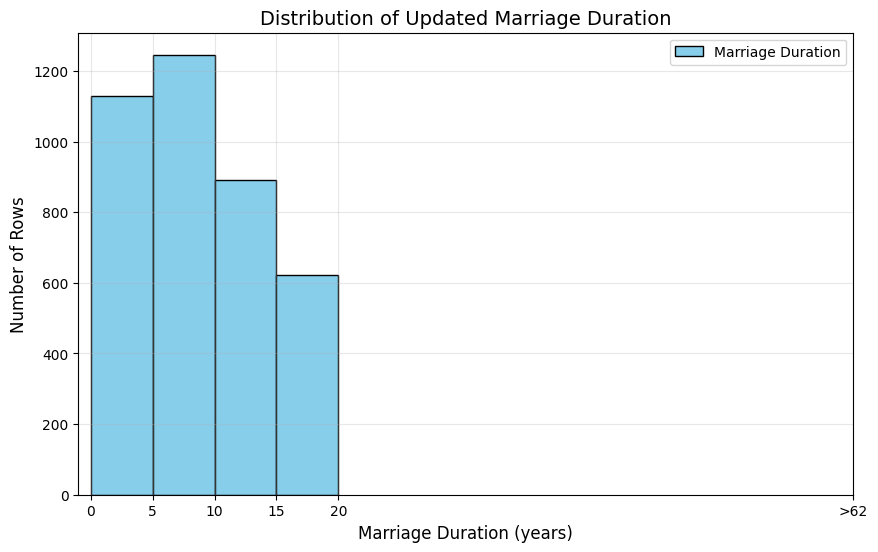


Summary of updated Marriage_duration:
count    4909.000000
mean       12.793115
std         9.515887
min         0.800000
25%         5.300000
50%        10.400000
75%        18.000000
max        61.600000
Name: Marriage_duration, dtype: float64

Summary of updated Marriage_duration_months:
count    4909.000000
mean      153.915013
std       114.182747
min         9.100000
25%        64.500000
50%       125.100000
75%       216.100000
max       739.000000
Name: Marriage_duration_months, dtype: float64

After updating durations:
  Divorce_date Date_of_marriage  Marriage_duration  Marriage_duration_months  \
0   2006-06-09       2000-06-26                5.9                      71.5   
1   2000-02-01       1977-02-17               22.9                     275.5   
2   2005-02-01       1975-12-18               29.1                     349.5   
3   2006-02-01       1987-12-03               18.1                     218.0   
4   2006-02-01       1998-11-14                7.2               

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from dateutil.relativedelta import relativedelta

# Update Marriage_duration and Marriage_duration_months based on Divorce_date and Date_of_marriage
def update_marriage_durations(df):
    # [Change 1]: Initialize new columns
    df['Marriage_duration'] = np.nan
    df['Marriage_duration_months'] = np.nan
    
    # [Change 2]: Calculate durations for valid date pairs
    mask_valid_dates = (
        df['Divorce_date'].notnull() & 
        df['Date_of_marriage'].notnull() & 
        (df['Divorce_date'] >= df['Date_of_marriage'])
    )
    
    # Calculate years and months using relativedelta
    for idx in df[mask_valid_dates].index:
        start_date = df.loc[idx, 'Date_of_marriage']
        end_date = df.loc[idx, 'Divorce_date']
        delta = relativedelta(end_date, start_date)
        
        # Calculate years with decimal precision
        years = delta.years + delta.months / 12 + delta.days / (365.25 * 12)
        df.loc[idx, 'Marriage_duration'] = round(years, 1)
        
        # Calculate total months
        total_months = delta.years * 12 + delta.months + delta.days / 30.42
        df.loc[idx, 'Marriage_duration_months'] = round(total_months, 1)
    
    # [Change 3]: Handle invalid cases (Divorce_date < Date_of_marriage)
    mask_invalid_dates = (
        df['Divorce_date'].notnull() & 
        df['Date_of_marriage'].notnull() & 
        (df['Divorce_date'] < df['Date_of_marriage'])
    )
    if mask_invalid_dates.any():
        print("Warning: Found rows with Divorce_date earlier than Date_of_marriage:")
        print(df[mask_invalid_dates][['Divorce_date', 'Date_of_marriage']])
        df.loc[mask_invalid_dates, 'Marriage_duration'] = np.nan
        df.loc[mask_invalid_dates, 'Marriage_duration_months'] = np.nan
    
    # [Change 4]: Plot histogram of updated Marriage_duration
    mask_valid_duration = df['Marriage_duration'].notnull()
    if mask_valid_duration.any():
        plt.figure(figsize=(10, 6))
        plt.hist(
            df.loc[mask_valid_duration, 'Marriage_duration'], 
            bins=[0, 5, 10, 15, 20, float('inf')], 
            edgecolor='black', 
            color='skyblue', 
            label='Marriage Duration'
        )
        plt.title('Distribution of Updated Marriage Duration', fontsize=14)
        plt.xlabel('Marriage Duration (years)', fontsize=12)
        plt.ylabel('Number of Rows', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.xticks([0, 5, 10, 15, 20, df['Marriage_duration'].max()], 
                   ['0', '5', '10', '15', '20', f'>{df["Marriage_duration"].max():.0f}'])
        plt.legend()
        plt.show()
    
    # [Change 5]: Print summary statistics
    print("\nSummary of updated Marriage_duration:")
    print(df['Marriage_duration'].describe())
    print("\nSummary of updated Marriage_duration_months:")
    print(df['Marriage_duration_months'].describe())
    
    return df

# Apply the update
df = update_marriage_durations(df)

# Check the result
print("\nAfter updating durations:")
print(df[['Divorce_date', 'Date_of_marriage', 'Marriage_duration', 
         'Marriage_duration_months', 'Num_Children']].head())

In [14]:
df.head()

,Divorce_date,DOB_partner_man,DOB_partner_woman,Date_of_marriage,Marriage_duration,Marriage_duration_months,Num_Children
0,2006-06-09,1975-12-18,1983-01-08,2000-06-26,5.9,71.5,1.0
1,2000-02-01,NaT,NaT,1977-02-17,22.9,275.5,NaN
2,2005-02-01,1955-02-22,1947-03-21,1975-12-18,29.1,349.5,NaN
3,2006-02-01,1964-01-20,NaT,1987-12-03,18.1,218.0,2.0
4,2006-02-01,1975-10-30,1978-10-13,1998-11-14,7.2,86.6,2.0
